Device: cuda
Found multispectral dataset: /kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSATallBands
Reading normalization values: 5000/22077
Reading normalization values: 10000/22077
Reading normalization values: 15000/22077
Reading normalization values: 20000/22077
Dataset: /kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSATallBands
Training images: 22077 Validation images: 5520
Epoch 1, Batch 1: first convolution gradient L2 = 0.6918411048350842
Epoch 1/20: D = 0.045338, G = -0.208186
Epoch 2/20: D = 6553.383093, G = 0.493317
Epoch 3/20: D = 17.054027, G = 1.000000
Epoch 4/20: D = 16.434739, G = 1.000000
Epoch 5/20: D = 15.729120, G = 1.000000
Epoch 6/20: D = 14.974172, G = 1.000000
Epoch 7/20: D = 14.136410, G = 1.000000
Epoch 8/20: D = 13.162002, G = 1.000000
Epoch 9/20: D = 11.834643, G = 1.000000
Epoch 10/20: D = 9.782988, G = 1.000000
Epoch 11/20: D = 6.601399, G = 1.000000
Epoch 12/20: D = 2.530470, G = 1.000000
Epoch 13/20: D = 3335.640863, G = -33.166972
Epoch 1

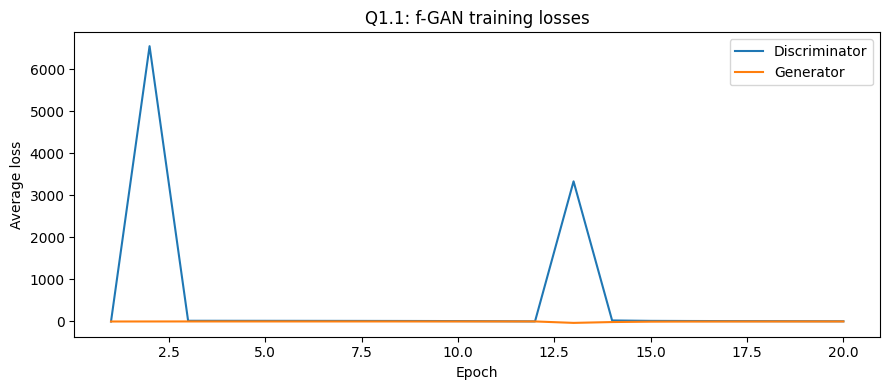

In [1]:
import os
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'

import random
from pathlib import Path

import numpy as np
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import rasterio
import matplotlib.pyplot as plt


SEED = 2026
DATA_ROOT =  Path('/kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSATallBands')
OUTPUT_DIR = Path('/kaggle/working/q1_1_fgan_simple')
BATCH_SIZE = 64
EPOCHS = 20
LATENT_DIM = 128
LEARNING_RATE = 0.0002


def set_seed():
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    torch.use_deterministic_algorithms(True)
    torch.backends.cuda.matmul.allow_tf32 = False
    torch.backends.cudnn.allow_tf32 = False


def read_image(path):
    with rasterio.open(path) as image:
        pixels = image.read(masked=True)
    if pixels.shape != (13, 64, 64):
        raise ValueError(f'{path}: expected 13 bands of size 64 x 64.')
    if np.ma.getmaskarray(pixels).any():
        raise ValueError(f'{path}: contains missing pixels.')
    pixels = np.asarray(pixels, dtype=np.float32)
    if not np.isfinite(pixels).all():
        raise ValueError(f'{path}: contains invalid pixel values.')
    return pixels


def find_dataset(search_root, classes):
    search_root = Path(search_root)
    if not search_root.is_dir():
        raise ValueError(f'Dataset directory does not exist: {search_root}')
    candidates, rejected, visited = [], [], set()
    required = {name.lower() for name in classes}

    # Find the class folders themselves, regardless of the enclosing folder's spelling.
    for directory, subfolders, _ in os.walk(search_root, followlinks=True):
        root = Path(directory)
        resolved = root.resolve()
        if resolved in visited:
            subfolders[:] = []
            continue
        visited.add(resolved)
        names = {name.lower(): name for name in subfolders}
        if not required.issubset(names):
            continue
        class_folders = {name: root / names[name.lower()] for name in classes}
        try:
            for folder in class_folders.values():
                sample = next((p for p in sorted(folder.rglob('*'))
                               if p.is_file() and p.suffix.lower() in ('.tif', '.tiff')), None)
                if sample is None:
                    raise ValueError(f'No TIFF images in {folder}')
                with rasterio.open(sample) as image:
                    if (image.count, image.height, image.width) != (13, 64, 64):
                        raise ValueError(f'{sample}: requires 13 bands, 64 x 64 pixels')
            candidates.append((root, class_folders))
        except (ValueError, rasterio.errors.RasterioIOError) as error:
            rejected.append(str(error))
        subfolders[:] = []

    if len(candidates) == 1:
        print('Found multispectral dataset:', candidates[0][0])
        return candidates[0]
    visible = [p.name for p in sorted(search_root.iterdir())][:20]
    raise ValueError(
        f'Found {len(candidates)} usable 13-band EuroSAT folders under {search_root}.\n'
        f'Candidates: {[str(root) for root, _ in candidates]}\n'
        f'Visible entries: {visible}\n'
        f'Rejected folders: {rejected[:5]}\n'
        'Attach the extracted EuroSATAllBands data. Set DATA_ROOT to its copied Kaggle '
        'directory path if needed; the folder may contain additional nesting.')


def prepare_data():
    root = DATA_ROOT
    if root is None:
        folders = sorted(p for p in Path('/kaggle/input').rglob('EuroSATAllBands')
                         if p.is_dir() and (p / 'AnnualCrop').is_dir())
        if len(folders) != 1:
            raise ValueError('Set DATA_ROOT to your EuroSATAllBands folder. '
                             f'Found these candidates: {folders}')
        root = folders[0]
    root = Path(root)
    classes = sorted(['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway',
                      'Industrial', 'Pasture', 'PermanentCrop', 'Residential',
                      'River', 'SeaLake'])
    root, class_folders = find_dataset(
        DATA_ROOT if DATA_ROOT is not None else '/kaggle/input', classes)
    train_files, validation_files = [], []
    rng = np.random.default_rng(SEED)

    # The guide uses a seeded 80/20 split within each class.
    for name in classes:
        files = sorted(p for p in (root / name).rglob('*'))
        files = sorted(p for p in class_folders[name].rglob('*')
                       if p.is_file() and p.suffix.lower() in ('.tif', '.tiff'))
        if len(files) < 2:
            raise ValueError(f'No usable TIFF class folder: {root / name}')
        order = rng.permutation(len(files))
        split = max(1, min(len(files) - 1, int(0.8 * len(files))))
        train_files.extend(files[i] for i in order[:split])
        validation_files.extend(files[i] for i in order[split:])
    train_files.sort()
    validation_files.sort()

    # Fit normalization using training images only, separately for each band.
    minimum = np.full(13, np.inf, dtype=np.float32)
    maximum = np.full(13, -np.inf, dtype=np.float32)
    for i, path in enumerate(train_files):
        image = read_image(path)
        minimum = np.minimum(minimum, image.min(axis=(1, 2)))
        maximum = np.maximum(maximum, image.max(axis=(1, 2)))
        if (i + 1) % 5000 == 0:
            print(f'Reading normalization values: {i + 1}/{len(train_files)}')
    if np.any(maximum <= minimum):
        raise ValueError('A band has no variation. Check the dataset.')
    print('Dataset:', root)
    print('Training images:', len(train_files), 'Validation images:', len(validation_files))
    return train_files, validation_files, minimum, maximum


class EuroSATDataset(Dataset):
    def __init__(self, files, minimum, maximum):
        self.files = files
        self.minimum = minimum[:, None, None]
        self.maximum = maximum[:, None, None]

    def __len__(self):
        return len(self.files)

    def __getitem__(self, index):
        image = read_image(self.files[index])
        image = 2 * (image - self.minimum) / (self.maximum - self.minimum) - 1
        return torch.from_numpy(image)


class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.ConvTranspose2d(LATENT_DIM, 256, 4, 1, 0)
        self.conv2 = nn.ConvTranspose2d(256, 128, 4, 2, 1)
        self.conv3 = nn.ConvTranspose2d(128, 64, 4, 2, 1)
        self.conv4 = nn.ConvTranspose2d(64, 32, 4, 2, 1)
        self.conv5 = nn.ConvTranspose2d(32, 13, 4, 2, 1)

    def forward(self, z):
        x = torch.relu(self.conv1(z))
        x = torch.relu(self.conv2(x))
        x = torch.relu(self.conv3(x))
        x = torch.relu(self.conv4(x))
        return torch.tanh(self.conv5(x))


def leaky_relu(x):
    return torch.where(x >= 0, x, 0.2 * x)


class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(13, 32, 4, 2, 1)
        self.conv2 = nn.Conv2d(32, 64, 4, 2, 1)
        self.conv3 = nn.Conv2d(64, 128, 4, 2, 1)
        self.conv4 = nn.Conv2d(128, 1, 3, 1, 1)

    def forward(self, x):
        x = leaky_relu(self.conv1(x))
        x = leaky_relu(self.conv2(x))
        x = leaky_relu(self.conv3(x))
        patches = self.conv4(x)
        scores = patches.mean(dim=(1, 2, 3))
        return scores  # g_f(v) = v: identity, because the domain is all real numbers.


def initialize_weights(layer):
    if isinstance(layer, (nn.Conv2d, nn.ConvTranspose2d)):
        nn.init.normal_(layer.weight, 0.0, 0.02)
        nn.init.zeros_(layer.bias)


def f_star(t):
    return torch.expm1(t)  # f*(t) = exp(t) - 1, for f(u) = u log(u) - u + 1.


def check_gradients(model):
    for parameter in model.parameters():
        if parameter.grad is None or not torch.isfinite(parameter.grad).all():
            raise FloatingPointError('Missing or nonfinite gradient; training stopped.')


def main():
    set_seed()
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print('Device:', device)
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    train_files, validation_files, minimum, maximum = prepare_data()
    dataset = EuroSATDataset(train_files, minimum, maximum)
    loader_rng = torch.Generator().manual_seed(SEED)
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True,
                        num_workers=0, generator=loader_rng)
    generator = Generator().to(device)
    discriminator = Discriminator().to(device)
    generator.apply(initialize_weights)
    discriminator.apply(initialize_weights)
    optimizer_g = torch.optim.Adam(generator.parameters(), lr=LEARNING_RATE, betas=(0.5, 0.999))
    optimizer_d = torch.optim.Adam(discriminator.parameters(), lr=LEARNING_RATE, betas=(0.5, 0.999))
    noise_rng = torch.Generator(device=device).manual_seed(SEED)
    d_history, g_history = [], []

    for epoch in range(EPOCHS):
        d_total, g_total, image_count = 0.0, 0.0, 0
        for batch_number, real in enumerate(loader):
            real = real.to(device)
            batch_size = real.shape[0]

            # Step 1: train the discriminator to maximize the variational bound.
            optimizer_d.zero_grad(set_to_none=True)
            z = torch.randn(batch_size, LATENT_DIM, 1, 1, device=device, generator=noise_rng)
            with torch.no_grad():
                fake = generator(z)
            real_scores = discriminator(real)
            fake_scores = discriminator(fake)
            loss_d = -real_scores.mean() + f_star(fake_scores).mean()
            if not torch.isfinite(loss_d):
                raise FloatingPointError('Nonfinite discriminator loss; training stopped.')
            loss_d.backward()

            # Capture the requested tensor BEFORE the first optimizer step.
            if epoch == 0 and batch_number == 0:
                gradient = discriminator.conv1.weight.grad.detach().cpu().clone()
                gradient_norm = gradient.double().square().sum().sqrt().item()
                if not np.isfinite(gradient_norm):
                    raise FloatingPointError('Nonfinite first gradient norm.')
                torch.save({'gradient': gradient, 'gradient_l2': gradient_norm},
                           OUTPUT_DIR / 'first_batch_gradient.pt')
                print('Epoch 1, Batch 1: first convolution gradient L2 =', repr(gradient_norm))

            check_gradients(discriminator)
            optimizer_d.step()
            optimizer_d.zero_grad(set_to_none=True)

            # Step 2: train the generator through the fixed discriminator.
            discriminator.requires_grad_(False)
            optimizer_g.zero_grad(set_to_none=True)
            z = torch.randn(batch_size, LATENT_DIM, 1, 1, device=device, generator=noise_rng)
            fake = generator(z)
            loss_g = -f_star(discriminator(fake)).mean()
            if not torch.isfinite(loss_g):
                raise FloatingPointError('Nonfinite generator loss; training stopped.')
            loss_g.backward()
            check_gradients(generator)
            optimizer_g.step()
            discriminator.requires_grad_(True)

            d_total += loss_d.item() * batch_size
            g_total += loss_g.item() * batch_size
            image_count += batch_size

        d_history.append(d_total / image_count)
        g_history.append(g_total / image_count)
        print(f'Epoch {epoch + 1}/{EPOCHS}: D = {d_history[-1]:.6f}, G = {g_history[-1]:.6f}')

    torch.save({'generator': generator.state_dict(), 'discriminator': discriminator.state_dict(),
                'minimum': torch.from_numpy(minimum), 'maximum': torch.from_numpy(maximum),
                'train_files': [str(p) for p in train_files],
                'validation_files': [str(p) for p in validation_files],
                'discriminator_losses': d_history, 'generator_losses': g_history,
                'seed': SEED, 'epochs': EPOCHS, 'batch_size': BATCH_SIZE,
                'latent_dim': LATENT_DIM, 'learning_rate': LEARNING_RATE,
                'gradient_l2': gradient_norm}, OUTPUT_DIR / 'fgan_results.pt')

    plt.figure(figsize=(9, 4))
    plt.plot(range(1, EPOCHS + 1), d_history, label='Discriminator')
    plt.plot(range(1, EPOCHS + 1), g_history, label='Generator')
    plt.xlabel('Epoch')
    plt.ylabel('Average loss')
    plt.title('Q1.1: f-GAN training losses')
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'training_losses.png')
    plt.show()


if __name__ == '__main__':
    main()

Device: cuda
Found multispectral dataset: /kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSATallBands
Reading normalization values: 5000/22077
Reading normalization values: 10000/22077
Reading normalization values: 15000/22077
Reading normalization values: 20000/22077
Dataset: /kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSATallBands
Training images: 22077 Validation images: 5520
Validation image 42: {'index': 42, 'path': '/kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSATallBands/AnnualCrop/AnnualCrop_1168.tif', 'class_name': 'AnnualCrop'}
Epoch 1/20: D=1.414566, G+E=1.479593
Epoch 2/20: D=1.399019, G+E=1.547384
Epoch 3/20: D=1.407933, G+E=1.759470
Epoch 4/20: D=1.292264, G+E=3.800640
Epoch 5/20: D=1.406545, G+E=1.633442
Epoch 6/20: D=1.383362, G+E=1.603834
Epoch 7/20: D=1.369132, G+E=1.784010
Epoch 8/20: D=1.357846, G+E=1.821439
Epoch 9/20: D=1.415593, G+E=1.755960
Epoch 10/20: D=1.384593, G+E=1.623882
Epoch 11/20: D=1.406822, G+E=1.632808
Epoch 12/20: D=1.401602

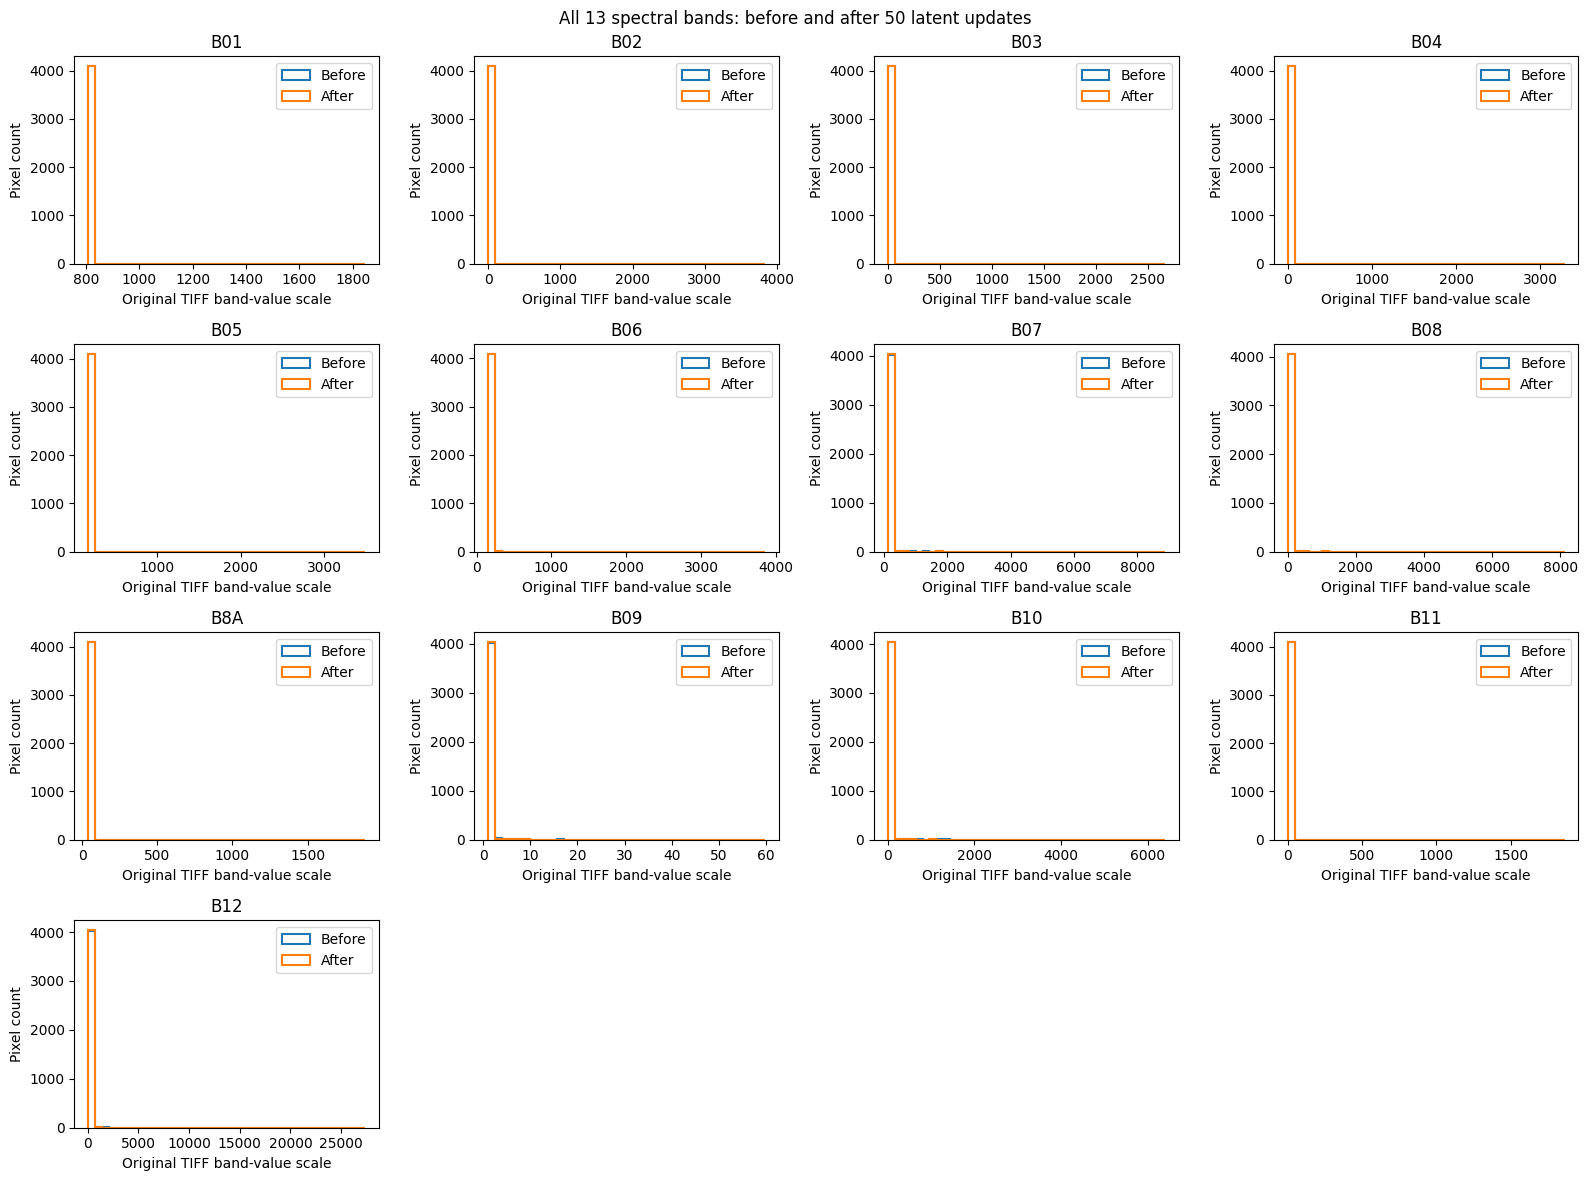

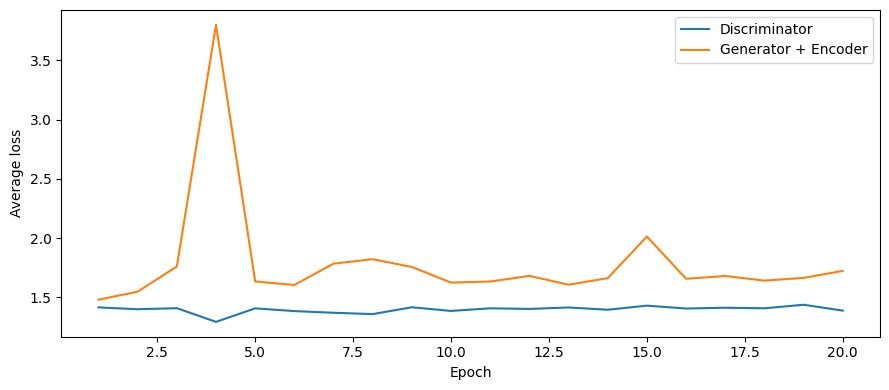

Saved outputs: /kaggle/working/q1_2_bigan_simple


In [2]:
import os
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'

import random
import json
from pathlib import Path

import numpy as np
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import rasterio
import matplotlib.pyplot as plt


SEED = 2026
DATA_ROOT = Path('/kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSATallBands')
OUTPUT_DIR = Path('/kaggle/working/q1_2_bigan_simple')
BATCH_SIZE = 64
EPOCHS = 20
LATENT_DIM = 128
LEARNING_RATE = 0.0002
ATTACK_STEPS = 50
ATTACK_LEARNING_RATE = 0.1


def set_seed():
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    torch.use_deterministic_algorithms(True)
    torch.backends.cuda.matmul.allow_tf32 = False
    torch.backends.cudnn.allow_tf32 = False


def read_image(path):
    with rasterio.open(path) as image:
        pixels = image.read(masked=True)
    if pixels.shape != (13, 64, 64):
        raise ValueError(f'{path}: expected 13 bands of size 64 x 64.')
    if np.ma.getmaskarray(pixels).any():
        raise ValueError(f'{path}: contains missing pixels.')
    pixels = np.asarray(pixels, dtype=np.float32)
    if not np.isfinite(pixels).all():
        raise ValueError(f'{path}: contains invalid pixel values.')
    return pixels


def find_dataset(search_root, classes):
    search_root = Path(search_root)
    if not search_root.is_dir():
        raise ValueError(f'Dataset directory does not exist: {search_root}')
    candidates, rejected, visited = [], [], set()
    required = {name.lower() for name in classes}

    # Find the class folders themselves, regardless of the enclosing folder's spelling.
    for directory, subfolders, _ in os.walk(search_root, followlinks=True):
        root = Path(directory)
        resolved = root.resolve()
        if resolved in visited:
            subfolders[:] = []
            continue
        visited.add(resolved)
        names = {name.lower(): name for name in subfolders}
        if not required.issubset(names):
            continue
        class_folders = {name: root / names[name.lower()] for name in classes}
        try:
            for folder in class_folders.values():
                sample = next((p for p in sorted(folder.rglob('*'))
                               if p.is_file() and p.suffix.lower() in ('.tif', '.tiff')), None)
                if sample is None:
                    raise ValueError(f'No TIFF images in {folder}')
                with rasterio.open(sample) as image:
                    if (image.count, image.height, image.width) != (13, 64, 64):
                        raise ValueError(f'{sample}: requires 13 bands, 64 x 64 pixels')
            candidates.append((root, class_folders))
        except (ValueError, rasterio.errors.RasterioIOError) as error:
            rejected.append(str(error))
        subfolders[:] = []

    if len(candidates) == 1:
        print('Found multispectral dataset:', candidates[0][0])
        return candidates[0]
    visible = [p.name for p in sorted(search_root.iterdir())][:20]
    raise ValueError(
        f'Found {len(candidates)} usable 13-band EuroSAT folders under {search_root}.\n'
        f'Candidates: {[str(root) for root, _ in candidates]}\n'
        f'Visible entries: {visible}\n'
        f'Rejected folders: {rejected[:5]}\n'
        'Attach the extracted EuroSATAllBands data. Set DATA_ROOT to its copied Kaggle '
        'directory path if needed; the folder may contain additional nesting.')


def prepare_data():
    classes = sorted(['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway',
                      'Industrial', 'Pasture', 'PermanentCrop', 'Residential',
                      'River', 'SeaLake'])
    root, class_folders = find_dataset(
        DATA_ROOT if DATA_ROOT is not None else '/kaggle/input', classes)
    train_files, validation_files = [], []
    rng = np.random.default_rng(SEED)

    # The guide uses a seeded 80/20 split within each class.
    for name in classes:
        files = sorted(p for p in class_folders[name].rglob('*')
                       if p.is_file() and p.suffix.lower() in ('.tif', '.tiff'))
        if len(files) < 2:
            raise ValueError(f'No usable TIFF class folder: {root / name}')
        order = rng.permutation(len(files))
        split = max(1, min(len(files) - 1, int(0.8 * len(files))))
        train_files.extend(files[i] for i in order[:split])
        validation_files.extend(files[i] for i in order[split:])
    train_files.sort()
    validation_files.sort()

    # Fit normalization using training images only, separately for each band.
    minimum = np.full(13, np.inf, dtype=np.float32)
    maximum = np.full(13, -np.inf, dtype=np.float32)
    for i, path in enumerate(train_files):
        image = read_image(path)
        minimum = np.minimum(minimum, image.min(axis=(1, 2)))
        maximum = np.maximum(maximum, image.max(axis=(1, 2)))
        if (i + 1) % 5000 == 0:
            print(f'Reading normalization values: {i + 1}/{len(train_files)}')
    if np.any(maximum <= minimum):
        raise ValueError('A band has no variation. Check the dataset.')
    print('Dataset:', root)
    print('Training images:', len(train_files), 'Validation images:', len(validation_files))
    return train_files, validation_files, minimum, maximum


class EuroSATDataset(Dataset):
    def __init__(self, files, minimum, maximum):
        self.files = files
        self.minimum = minimum[:, None, None]
        self.maximum = maximum[:, None, None]

    def __len__(self):
        return len(self.files)

    def __getitem__(self, index):
        image = read_image(self.files[index])
        image = 2 * (image - self.minimum) / (self.maximum - self.minimum) - 1
        return torch.from_numpy(image)


class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.ConvTranspose2d(LATENT_DIM, 256, 4, 1, 0)
        self.conv2 = nn.ConvTranspose2d(256, 128, 4, 2, 1)
        self.conv3 = nn.ConvTranspose2d(128, 64, 4, 2, 1)
        self.conv4 = nn.ConvTranspose2d(64, 32, 4, 2, 1)
        self.conv5 = nn.ConvTranspose2d(32, 13, 4, 2, 1)

    def forward(self, z):
        x = torch.relu(self.conv1(z.reshape(-1, LATENT_DIM, 1, 1)))
        x = torch.relu(self.conv2(x))
        x = torch.relu(self.conv3(x))
        x = torch.relu(self.conv4(x))
        return torch.tanh(self.conv5(x))


def leaky_relu(x):
    return torch.where(x >= 0, x, 0.2 * x)


class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(13, 32, 4, 2, 1)
        self.conv2 = nn.Conv2d(32, 64, 4, 2, 1)
        self.conv3 = nn.Conv2d(64, 128, 4, 2, 1)
        self.latent = nn.Linear(128 * 8 * 8, LATENT_DIM)

    def forward(self, x):
        x = leaky_relu(self.conv1(x))
        x = leaky_relu(self.conv2(x))
        x = leaky_relu(self.conv3(x))
        return self.latent(x.flatten(1))


def broadcast_latent(x, z):
    # [B,128] -> [B,128,1,1] -> [B,128,64,64].
    assert z.shape == (x.shape[0], LATENT_DIM)
    z_image = z[:, :, None, None].expand(-1, -1, x.shape[2], x.shape[3])
    return torch.cat([x, z_image], dim=1)  # [B,141,64,64]


class JointDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(13 + LATENT_DIM, 32, 4, 2, 1)
        self.conv2 = nn.Conv2d(32, 64, 4, 2, 1)
        self.conv3 = nn.Conv2d(64, 128, 4, 2, 1)
        self.conv4 = nn.Conv2d(128, 1, 3, 1, 1)

    def forward(self, x, z):
        pair = broadcast_latent(x, z)
        h = leaky_relu(self.conv1(pair))
        h = leaky_relu(self.conv2(h))
        h = leaky_relu(self.conv3(h))
        return self.conv4(h).mean(dim=(1, 2, 3))  # One raw logit per joint pair.


def initialize_weights(layer):
    if isinstance(layer, (nn.Conv2d, nn.ConvTranspose2d, nn.Linear)):
        nn.init.normal_(layer.weight, 0.0, 0.02)
        nn.init.zeros_(layer.bias)


def binary_loss(logits, target):
    # Stable binary cross entropy: log(1 + exp(logit)) - target * logit.
    return (torch.logaddexp(torch.zeros_like(logits), logits) - target * logits).mean()


def check_gradients(model):
    for parameter in model.parameters():
        if parameter.grad is None or not torch.isfinite(parameter.grad).all():
            raise FloatingPointError('Missing or nonfinite gradient; training stopped.')


def latent_attack(generator, encoder, discriminator, device):
    for model in (generator, encoder, discriminator):
        model.eval()
        model.zero_grad(set_to_none=True)
        model.requires_grad_(False)

    # Dedicated RNG: the initial attack vector does not depend on training RNG consumption.
    attack_rng = torch.Generator(device=device).manual_seed(SEED)
    z_attack = torch.randn(1, LATENT_DIM, device=device, generator=attack_rng)
    z_initial = z_attack.detach().clone()
    z_attack.requires_grad_(True)
    with torch.no_grad():
        image_before = generator(z_attack).cpu().clone()
        probability_before = discriminator(generator(z_attack), z_attack).sigmoid().item()

    attack_log_probability = []
    assert ATTACK_STEPS == 50, 'Q1.2 requires exactly 50 updates.'
    for step in range(ATTACK_STEPS):
        generated = generator(z_attack)
        logit = discriminator(generated, z_attack)
        # Ascend log(sigmoid(D(G(z),z))) to make the generated pair look real.
        objective = -torch.logaddexp(torch.zeros_like(logit), -logit).mean()
        if not torch.isfinite(objective):
            raise FloatingPointError('Nonfinite latent attack objective.')
        gradient = torch.autograd.grad(objective, z_attack)[0]
        if not torch.isfinite(gradient).all():
            raise FloatingPointError('Nonfinite latent attack gradient.')
        attack_log_probability.append(objective.item())
        with torch.no_grad():
            z_attack.add_(ATTACK_LEARNING_RATE * gradient)  # Gradient ASCENT; only z changes.
        if not torch.isfinite(z_attack).all():
            raise FloatingPointError('Nonfinite attack latent.')

    z_final = z_attack.detach().clone()
    with torch.no_grad():
        image_after = generator(z_final).cpu().clone()
        final_logit = discriminator(generator(z_final), z_final)
        probability_after = final_logit.sigmoid().item()
        attack_log_probability.append(-torch.logaddexp(torch.zeros_like(final_logit), -final_logit).mean().item())
    # Float64 reduction of the actual saved float32 latent vectors.
    distance = (z_final.cpu().double() - z_initial.cpu().double()).square().sum().sqrt().item()
    if not np.isfinite(distance):
        raise FloatingPointError('Nonfinite latent displacement.')
    return dict(z_initial=z_initial.cpu(), z_final=z_final.cpu(),
                image_before=image_before, image_after=image_after,
                distance=distance, probability_before=probability_before,
                probability_after=probability_after, log_probability=attack_log_probability)


def plot_histograms(attack, minimum, maximum):
    # Convert generated values back to the original TIFF band-value scale.
    before = (attack['image_before'][0].numpy() + 1) / 2
    after = (attack['image_after'][0].numpy() + 1) / 2
    before = before * (maximum - minimum)[:, None, None] + minimum[:, None, None]
    after = after * (maximum - minimum)[:, None, None] + minimum[:, None, None]
    bands = ['B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07',
             'B08', 'B8A', 'B09', 'B10', 'B11', 'B12']
    fig, axes = plt.subplots(4, 4, figsize=(16, 12))
    for band, ax in enumerate(axes.flat):
        if band >= 13:
            ax.set_visible(False)
            continue
        low = min(before[band].min(), after[band].min())
        high = max(before[band].max(), after[band].max())
        if high <= low:
            high = low + 1
        bins = np.linspace(low, high, 41)  # Same bins before and after within a band.
        ax.hist(before[band].ravel(), bins=bins, histtype='step', label='Before', linewidth=1.5)
        ax.hist(after[band].ravel(), bins=bins, histtype='step', label='After', linewidth=1.5)
        ax.set(title=bands[band], xlabel='Original TIFF band-value scale', ylabel='Pixel count')
        ax.legend()
    fig.suptitle('All 13 spectral bands: before and after 50 latent updates')
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / 'spectral_histograms_before_after.png', dpi=150)
    plt.show()


def main():
    set_seed()
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print('Device:', device)
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    # Identical preprocessing to Q1_1_FGAN.py for the same attached dataset.
    train_files, validation_files, minimum, maximum = prepare_data()
    train_data = EuroSATDataset(train_files, minimum, maximum)
    validation_data = EuroSATDataset(validation_files, minimum, maximum)
    if len(validation_data) <= 42:
        raise ValueError('The validation set must contain image index 42.')
    x_real = validation_data[42].unsqueeze(0)
    validation_info = dict(index=42, path=str(validation_files[42]),
                           class_name=validation_files[42].parent.name)
    print('Validation image 42:', validation_info)
    # The guide clarifies that x_real is recorded, not encoded or added to the attack loss.
    # The specified attacked pair is (G(z_attack), z_attack); no reconstruction target is used.
    loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, num_workers=0,
                        generator=torch.Generator().manual_seed(SEED))
    generator = Generator().to(device)
    encoder = Encoder().to(device)
    discriminator = JointDiscriminator().to(device)
    for model in (generator, encoder, discriminator):
        model.apply(initialize_weights)
    optimizer_d = torch.optim.Adam(discriminator.parameters(), lr=LEARNING_RATE, betas=(0.5, 0.999))
    optimizer_ge = torch.optim.Adam(list(generator.parameters()) + list(encoder.parameters()),
                                    lr=LEARNING_RATE, betas=(0.5, 0.999))
    noise_rng = torch.Generator(device=device).manual_seed(SEED)
    d_history, ge_history = [], []

    for epoch in range(EPOCHS):
        d_total, ge_total, count = 0.0, 0.0, 0
        for real in loader:
            real = real.to(device)
            batch_size = len(real)
            z = torch.randn(batch_size, LATENT_DIM, device=device, generator=noise_rng)

            # D: (real,E(real)) is real; (G(z),z) is fake.
            optimizer_d.zero_grad(set_to_none=True)
            with torch.no_grad():
                encoded = encoder(real)
                generated = generator(z)
            loss_d = (binary_loss(discriminator(real, encoded), 1.0)
                      + binary_loss(discriminator(generated, z), 0.0))
            if not torch.isfinite(loss_d):
                raise FloatingPointError('Nonfinite discriminator loss.')
            loss_d.backward()
            check_gradients(discriminator)
            optimizer_d.step()
            optimizer_d.zero_grad(set_to_none=True)

            # Guide-approved label-swapped loss: E and G try to fool the fixed D.
            discriminator.requires_grad_(False)
            try:
                optimizer_ge.zero_grad(set_to_none=True)
                z = torch.randn(batch_size, LATENT_DIM, device=device, generator=noise_rng)
                loss_ge = (binary_loss(discriminator(real, encoder(real)), 0.0)
                           + binary_loss(discriminator(generator(z), z), 1.0))
                if not torch.isfinite(loss_ge):
                    raise FloatingPointError('Nonfinite generator/encoder loss.')
                loss_ge.backward()
                check_gradients(generator)
                check_gradients(encoder)
                optimizer_ge.step()
            finally:
                discriminator.requires_grad_(True)
            d_total += loss_d.item() * batch_size
            ge_total += loss_ge.item() * batch_size
            count += batch_size
        d_history.append(d_total / count)
        ge_history.append(ge_total / count)
        print(f'Epoch {epoch + 1}/{EPOCHS}: D={d_history[-1]:.6f}, G+E={ge_history[-1]:.6f}')

    torch.save(dict(generator=generator.state_dict(), encoder=encoder.state_dict(),
                    discriminator=discriminator.state_dict(), seed=SEED, epochs=EPOCHS,
                    batch_size=BATCH_SIZE, latent_dim=LATENT_DIM, learning_rate=LEARNING_RATE,
                    minimum=torch.from_numpy(minimum), maximum=torch.from_numpy(maximum),
                    train_files=[str(p) for p in train_files], validation_files=[str(p) for p in validation_files],
                    discriminator_loss=d_history, generator_encoder_loss=ge_history),
               OUTPUT_DIR / 'bigan_model.pt')

    attack = latent_attack(generator, encoder, discriminator, device)
    torch.save(dict(**attack, x_real_index42=x_real, validation_info=validation_info,
                    attack_steps=ATTACK_STEPS, attack_learning_rate=ATTACK_LEARNING_RATE),
               OUTPUT_DIR / 'latent_attack.pt')
    results = dict(q1_2_zattack_l2_distance_50steps=attack['distance'],
                   probability_real_before=attack['probability_before'],
                   probability_real_after=attack['probability_after'],
                   attack_steps=ATTACK_STEPS, attack_learning_rate=ATTACK_LEARNING_RATE,
                   validation_image=validation_info)
    (OUTPUT_DIR / 'results.json').write_text(json.dumps(results, indent=2, allow_nan=False))
    print('Exact ||z_50 - z_0||_2:', repr(attack['distance']))
    print('D probability of real, before/after:', attack['probability_before'], attack['probability_after'])
    plot_histograms(attack, minimum, maximum)

    plt.figure(figsize=(9, 4))
    plt.plot(range(1, EPOCHS + 1), d_history, label='Discriminator')
    plt.plot(range(1, EPOCHS + 1), ge_history, label='Generator + Encoder')
    plt.xlabel('Epoch')
    plt.ylabel('Average loss')
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'training_losses.png')
    plt.show()
    print('Saved outputs:', OUTPUT_DIR)


if __name__ == '__main__':
    main()


Device: cuda
Found multispectral dataset: /kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSATallBands
Reading normalization values: 5000/22077
Reading normalization values: 10000/22077
Reading normalization values: 15000/22077
Reading normalization values: 20000/22077
Dataset: /kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSATallBands
Training images: 22077 Validation images: 5520
Epoch 1 Batch 1, epsilon=0.5, UNSCALED gradient penalty: 0.9948620796203613
Epoch 1/20: critic=-128.270528, generator=-208.522268, GP=4.978252
Epoch 2/20: critic=-34.986698, generator=199.640323, GP=1.081839
Epoch 3/20: critic=-42.033277, generator=446.292247, GP=1.670081
Epoch 4/20: critic=-34.855104, generator=374.197609, GP=1.126221
Epoch 5/20: critic=-17.323024, generator=175.079638, GP=0.372572
Epoch 6/20: critic=-9.213640, generator=54.706674, GP=0.149950
Epoch 7/20: critic=-2.606560, generator=-7.002880, GP=0.036707
Epoch 8/20: critic=-3.710644, generator=1.758639, GP=0.045466
Epoch 9/20: 

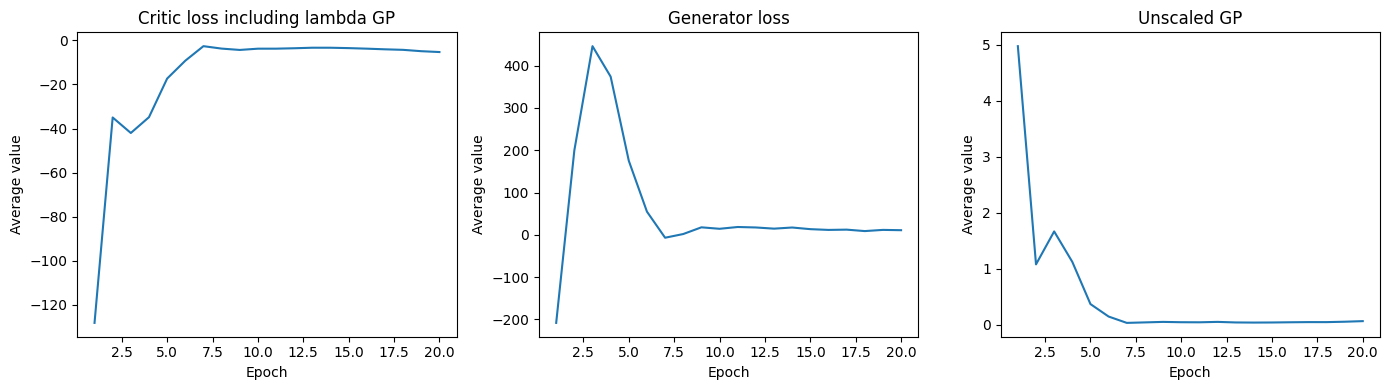

Required unscaled first-batch GP: 0.9948620796203613
Saved 13-band samples and models in: /kaggle/working/q1_3_wgan_gp_simple


In [3]:
import os
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'

import random
import json
from pathlib import Path

import numpy as np
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import rasterio
import matplotlib.pyplot as plt


SEED = 2026
DATA_ROOT = None  # Or Path('/kaggle/input/your-dataset/EuroSATAllBands')
OUTPUT_DIR = Path('/kaggle/working/q1_3_wgan_gp_simple')
BATCH_SIZE = 64
EPOCHS = 20
LATENT_DIM = 128
LEARNING_RATE = 0.0001
GP_WEIGHT = 10.0
CRITIC_STEPS = 5


def set_seed():
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    torch.use_deterministic_algorithms(True)
    torch.backends.cuda.matmul.allow_tf32 = False
    torch.backends.cudnn.allow_tf32 = False


def read_image(path):
    with rasterio.open(path) as image:
        pixels = image.read(masked=True)
    if pixels.shape != (13, 64, 64):
        raise ValueError(f'{path}: expected 13 bands of size 64 x 64.')
    if np.ma.getmaskarray(pixels).any():
        raise ValueError(f'{path}: contains missing pixels.')
    pixels = np.asarray(pixels, dtype=np.float32)
    if not np.isfinite(pixels).all():
        raise ValueError(f'{path}: contains invalid pixel values.')
    return pixels


def find_dataset(search_root, classes):
    search_root = Path(search_root)
    if not search_root.is_dir():
        raise ValueError(f'Dataset directory does not exist: {search_root}')
    candidates, rejected, visited = [], [], set()
    required = {name.lower() for name in classes}

    # Find the class folders themselves, regardless of the enclosing folder's spelling.
    for directory, subfolders, _ in os.walk(search_root, followlinks=True):
        root = Path(directory)
        resolved = root.resolve()
        if resolved in visited:
            subfolders[:] = []
            continue
        visited.add(resolved)
        names = {name.lower(): name for name in subfolders}
        if not required.issubset(names):
            continue
        class_folders = {name: root / names[name.lower()] for name in classes}
        try:
            for folder in class_folders.values():
                sample = next((p for p in sorted(folder.rglob('*'))
                               if p.is_file() and p.suffix.lower() in ('.tif', '.tiff')), None)
                if sample is None:
                    raise ValueError(f'No TIFF images in {folder}')
                with rasterio.open(sample) as image:
                    if (image.count, image.height, image.width) != (13, 64, 64):
                        raise ValueError(f'{sample}: requires 13 bands, 64 x 64 pixels')
            candidates.append((root, class_folders))
        except (ValueError, rasterio.errors.RasterioIOError) as error:
            rejected.append(str(error))
        subfolders[:] = []

    if len(candidates) == 1:
        print('Found multispectral dataset:', candidates[0][0])
        return candidates[0]
    visible = [p.name for p in sorted(search_root.iterdir())][:20]
    raise ValueError(
        f'Found {len(candidates)} usable 13-band EuroSAT folders under {search_root}.\n'
        f'Candidates: {[str(root) for root, _ in candidates]}\n'
        f'Visible entries: {visible}\n'
        f'Rejected folders: {rejected[:5]}\n'
        'Attach the extracted EuroSATAllBands data. Set DATA_ROOT to its copied Kaggle '
        'directory path if needed; the folder may contain additional nesting.')


def prepare_data():
    classes = sorted(['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway',
                      'Industrial', 'Pasture', 'PermanentCrop', 'Residential',
                      'River', 'SeaLake'])
    root, class_folders = find_dataset(
        DATA_ROOT if DATA_ROOT is not None else '/kaggle/input', classes)
    train_files, validation_files = [], []
    rng = np.random.default_rng(SEED)

    # The guide uses a seeded 80/20 split within each class.
    for name in classes:
        files = sorted(p for p in class_folders[name].rglob('*')
                       if p.is_file() and p.suffix.lower() in ('.tif', '.tiff'))
        if len(files) < 2:
            raise ValueError(f'No usable TIFF class folder: {root / name}')
        order = rng.permutation(len(files))
        split = max(1, min(len(files) - 1, int(0.8 * len(files))))
        train_files.extend(files[i] for i in order[:split])
        validation_files.extend(files[i] for i in order[split:])
    train_files.sort()
    validation_files.sort()

    # Fit normalization using training images only, separately for each band.
    minimum = np.full(13, np.inf, dtype=np.float32)
    maximum = np.full(13, -np.inf, dtype=np.float32)
    for i, path in enumerate(train_files):
        image = read_image(path)
        minimum = np.minimum(minimum, image.min(axis=(1, 2)))
        maximum = np.maximum(maximum, image.max(axis=(1, 2)))
        if (i + 1) % 5000 == 0:
            print(f'Reading normalization values: {i + 1}/{len(train_files)}')
    if np.any(maximum <= minimum):
        raise ValueError('A band has no variation. Check the dataset.')
    print('Dataset:', root)
    print('Training images:', len(train_files), 'Validation images:', len(validation_files))
    return train_files, validation_files, minimum, maximum


class EuroSATDataset(Dataset):
    def __init__(self, files, minimum, maximum):
        self.files = files
        self.minimum = minimum[:, None, None]
        self.maximum = maximum[:, None, None]

    def __len__(self):
        return len(self.files)

    def __getitem__(self, index):
        image = read_image(self.files[index])
        image = 2 * (image - self.minimum) / (self.maximum - self.minimum) - 1
        return torch.from_numpy(image)


class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.ConvTranspose2d(LATENT_DIM, 256, 4, 1, 0)
        self.conv2 = nn.ConvTranspose2d(256, 128, 4, 2, 1)
        self.conv3 = nn.ConvTranspose2d(128, 64, 4, 2, 1)
        self.conv4 = nn.ConvTranspose2d(64, 32, 4, 2, 1)
        self.conv5 = nn.ConvTranspose2d(32, 13, 4, 2, 1)

    def forward(self, z):
        x = torch.relu(self.conv1(z))
        x = torch.relu(self.conv2(x))
        x = torch.relu(self.conv3(x))
        x = torch.relu(self.conv4(x))
        return torch.tanh(self.conv5(x))


def leaky_relu(x):
    return torch.where(x >= 0, x, 0.2 * x)



class Critic(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(13, 32, 4, 2, 1)
        self.conv2 = nn.Conv2d(32, 64, 4, 2, 1)
        self.conv3 = nn.Conv2d(64, 128, 4, 2, 1)
        self.conv4 = nn.Conv2d(128, 1, 3, 1, 1)

    def forward(self, x):
        x = leaky_relu(self.conv1(x))
        x = leaky_relu(self.conv2(x))
        x = leaky_relu(self.conv3(x))
        return self.conv4(x).mean(dim=(1, 2, 3))  # One real score per image; no sigmoid.


def initialize_weights(layer):
    if isinstance(layer, (nn.Conv2d, nn.ConvTranspose2d)):
        nn.init.normal_(layer.weight, 0.0, 0.02)
        nn.init.zeros_(layer.bias)


def gradient_penalty(critic, real, fake, epsilon):
    # x_hat = epsilon * real + (1-epsilon) * fake.
    # Detach the endpoints so this critic update cannot train the generator.
    # x_hat itself remains attached to the critic graph and requires input gradients.
    x_hat = epsilon * real.detach() + (1 - epsilon) * fake.detach()
    x_hat.requires_grad_(True)
    scores = critic(x_hat)
    gradients = torch.autograd.grad(outputs=scores, inputs=x_hat,
                                    grad_outputs=torch.ones_like(scores),
                                    create_graph=True)[0]
    norms = torch.linalg.vector_norm(gradients.flatten(1), ord=2, dim=1)
    gp = ((norms - 1) ** 2).mean()  # Unscaled: mean of squared differences, not square of mean.
    return gp, norms, x_hat


def check_gradients(model):
    for parameter in model.parameters():
        if parameter.grad is None or not torch.isfinite(parameter.grad).all():
            raise FloatingPointError('Missing or nonfinite gradient; training stopped.')


def main():
    set_seed()
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print('Device:', device)
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    # Same split and normalization as Q1_1_FGAN.py for identical input TIFF files.
    train_files, validation_files, minimum, maximum = prepare_data()
    dataset = EuroSATDataset(train_files, minimum, maximum)
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0,
                        generator=torch.Generator().manual_seed(SEED))
    generator = Generator().to(device)
    critic = Critic().to(device)
    generator.apply(initialize_weights)
    critic.apply(initialize_weights)
    optimizer_g = torch.optim.Adam(generator.parameters(), lr=LEARNING_RATE, betas=(0.0, 0.9))
    optimizer_c = torch.optim.Adam(critic.parameters(), lr=LEARNING_RATE, betas=(0.0, 0.9))
    noise_rng = torch.Generator(device=device).manual_seed(SEED)
    epsilon_rng = torch.Generator(device=device).manual_seed(SEED)
    first_gp = None
    history = []

    for epoch in range(1, EPOCHS + 1):
        critic_total, gp_total, generator_total = 0.0, 0.0, 0.0
        critic_examples, generator_examples = 0, 0
        for batch_number, real in enumerate(loader, start=1):
            real = real.to(device)
            batch_size = len(real)
            optimizer_c.zero_grad(set_to_none=True)
            z = torch.randn(batch_size, LATENT_DIM, 1, 1, device=device, generator=noise_rng)
            with torch.no_grad():
                fake = generator(z)

            if epoch == 1 and batch_number == 1:
                epsilon = torch.full((batch_size, 1, 1, 1), 0.5, device=device)
            else:
                epsilon = torch.rand(batch_size, 1, 1, 1, device=device, generator=epsilon_rng)
            gp, norms, x_hat = gradient_penalty(critic, real, fake, epsilon)
            if not torch.isfinite(gp):
                raise FloatingPointError('Nonfinite gradient penalty.')

            if epoch == 1 and batch_number == 1:
                assert torch.all(epsilon == 0.5)
                first_gp = gp.item()  # Capture before any optimizer step; no lambda multiplier.
                torch.save(dict(unscaled_gp=first_gp, epsilon=epsilon.cpu(),
                                gradient_norms=norms.detach().cpu(),
                                interpolated_images=x_hat.detach().cpu()),
                           OUTPUT_DIR / 'first_batch_gp.pt')
                print('Epoch 1 Batch 1, epsilon=0.5, UNSCALED gradient penalty:', repr(first_gp))

            # Critic minimizes fake score - real score + lambda * GP.
            loss_c = critic(fake).mean() - critic(real).mean() + GP_WEIGHT * gp
            if not torch.isfinite(loss_c):
                raise FloatingPointError('Nonfinite critic loss.')
            loss_c.backward()
            check_gradients(critic)
            optimizer_c.step()
            optimizer_c.zero_grad(set_to_none=True)
            critic_total += loss_c.item() * batch_size
            gp_total += gp.item() * batch_size
            critic_examples += batch_size

            # Five fresh real minibatches per G update; finish a short group at epoch end.
            if batch_number % CRITIC_STEPS == 0 or batch_number == len(loader):
                critic.requires_grad_(False)
                try:
                    optimizer_g.zero_grad(set_to_none=True)
                    z = torch.randn(batch_size, LATENT_DIM, 1, 1, device=device, generator=noise_rng)
                    loss_g = -critic(generator(z)).mean()
                    if not torch.isfinite(loss_g):
                        raise FloatingPointError('Nonfinite generator loss.')
                    loss_g.backward()
                    check_gradients(generator)
                    optimizer_g.step()
                finally:
                    critic.requires_grad_(True)
                generator_total += loss_g.item() * batch_size
                generator_examples += batch_size

        row = dict(epoch=epoch, critic_loss=critic_total / critic_examples,
                   generator_loss=generator_total / generator_examples,
                   unscaled_gp=gp_total / critic_examples)
        history.append(row)
        print(f"Epoch {epoch}/{EPOCHS}: critic={row['critic_loss']:.6f}, "
              f"generator={row['generator_loss']:.6f}, GP={row['unscaled_gp']:.6f}")

    assert first_gp is not None
    results = dict(q1_3_gp_unscaled_e1_b1_eps_0_5=first_gp)
    (OUTPUT_DIR / 'results.json').write_text(json.dumps(results, indent=2, allow_nan=False))
    (OUTPUT_DIR / 'training_history.json').write_text(json.dumps(history, indent=2, allow_nan=False))
    torch.save(dict(generator=generator.state_dict(), critic=critic.state_dict(),
                    latent_dim=LATENT_DIM, seed=SEED, epochs=EPOCHS, batch_size=BATCH_SIZE,
                    learning_rate=LEARNING_RATE, gp_weight=GP_WEIGHT, critic_steps=CRITIC_STEPS,
                    minimum=torch.from_numpy(minimum), maximum=torch.from_numpy(maximum),
                    train_files=[str(p) for p in train_files], validation_files=[str(p) for p in validation_files],
                    results=results, history=history), OUTPUT_DIR / 'wgan_gp_model.pt')

    generator.eval()
    sample_rng = torch.Generator(device=device).manual_seed(SEED + 1)
    with torch.no_grad():
        z = torch.randn(8, LATENT_DIM, 1, 1, device=device, generator=sample_rng)
        generated = generator(z).cpu()
    assert generated.shape == (8, 13, 64, 64) and torch.isfinite(generated).all()
    torch.save(generated, OUTPUT_DIR / 'generated_13band_samples.pt')
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for ax, key, title in zip(axes, ['critic_loss', 'generator_loss', 'unscaled_gp'],
                             ['Critic loss including lambda GP', 'Generator loss', 'Unscaled GP']):
        ax.plot([r['epoch'] for r in history], [r[key] for r in history])
        ax.set(title=title, xlabel='Epoch', ylabel='Average value')
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / 'training_curves.png', dpi=150)
    plt.show()
    print('Required unscaled first-batch GP:', repr(first_gp))
    print('Saved 13-band samples and models in:', OUTPUT_DIR)


if __name__ == '__main__':
    main()

Device: cuda
Found multispectral dataset: /kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSATallBands
Using trained generator: /kaggle/working/q1_3_wgan_gp_simple/wgan_gp_model.pt
Epoch 1/20: loss=1.8630, train accuracy=0.287, validation accuracy=0.359
Epoch 2/20: loss=1.5510, train accuracy=0.420, validation accuracy=0.485
Epoch 3/20: loss=1.4193, train accuracy=0.458, validation accuracy=0.492
Epoch 4/20: loss=1.2953, train accuracy=0.525, validation accuracy=0.620
Epoch 5/20: loss=1.1095, train accuracy=0.598, validation accuracy=0.614
Epoch 6/20: loss=1.0430, train accuracy=0.621, validation accuracy=0.654
Epoch 7/20: loss=0.9759, train accuracy=0.648, validation accuracy=0.671
Epoch 8/20: loss=0.9497, train accuracy=0.655, validation accuracy=0.697
Epoch 9/20: loss=0.9135, train accuracy=0.672, validation accuracy=0.696
Epoch 10/20: loss=0.8286, train accuracy=0.707, validation accuracy=0.688
Epoch 11/20: loss=0.7892, train accuracy=0.721, validation accuracy=0.723
Epoch 12/

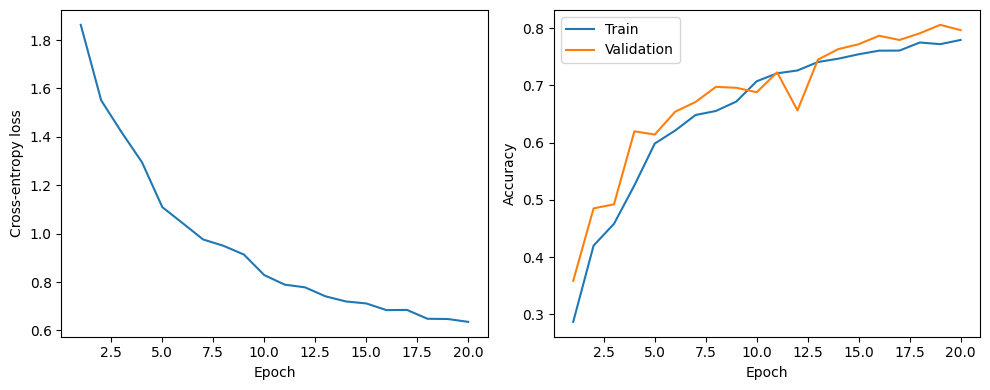

Saved outputs: /kaggle/working/q1_4_ffd_simple


In [4]:
import os
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
import random
import json
from pathlib import Path
import numpy as np
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, Subset
import rasterio
import matplotlib.pyplot as plt

SEED = 2026
DATA_ROOT = Path('/kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSATallBands')
WGAN_CHECKPOINT = Path('/kaggle/working/q1_3_wgan_gp_simple/wgan_gp_model.pt')
OUTPUT_DIR = Path('/kaggle/working/q1_4_ffd_simple')
BATCH_SIZE = 64
EPOCHS = 20
LATENT_DIM = 128
FEATURE_DIM = 128
NUM_IMAGES = 1000
LEARNING_RATE = 0.001
CLASSES = sorted(['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway',
                  'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake'])


def set_seed():
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    torch.use_deterministic_algorithms(True)
    torch.backends.cuda.matmul.allow_tf32 = False
    torch.backends.cudnn.allow_tf32 = False


def read_image(path):
    with rasterio.open(path) as image:
        pixels = image.read(masked=True)
    if pixels.shape != (13, 64, 64):
        raise ValueError(f'{path}: expected 13 bands of size 64 x 64.')
    if np.ma.getmaskarray(pixels).any():
        raise ValueError(f'{path}: contains missing pixels.')
    pixels = np.asarray(pixels, dtype=np.float32)
    if not np.isfinite(pixels).all():
        raise ValueError(f'{path}: contains invalid pixel values.')
    return pixels


def find_dataset(search_root, classes):
    search_root = Path(search_root)
    if not search_root.is_dir():
        raise ValueError(f'Dataset directory does not exist: {search_root}')
    candidates, rejected, visited = [], [], set()
    required = {name.lower() for name in classes}

    # Find the class folders themselves, regardless of the enclosing folder's spelling.
    for directory, subfolders, _ in os.walk(search_root, followlinks=True):
        root = Path(directory)
        resolved = root.resolve()
        if resolved in visited:
            subfolders[:] = []
            continue
        visited.add(resolved)
        names = {name.lower(): name for name in subfolders}
        if not required.issubset(names):
            continue
        class_folders = {name: root / names[name.lower()] for name in classes}
        try:
            for folder in class_folders.values():
                sample = next((p for p in sorted(folder.rglob('*'))
                               if p.is_file() and p.suffix.lower() in ('.tif', '.tiff')), None)
                if sample is None:
                    raise ValueError(f'No TIFF images in {folder}')
                with rasterio.open(sample) as image:
                    if (image.count, image.height, image.width) != (13, 64, 64):
                        raise ValueError(f'{sample}: requires 13 bands, 64 x 64 pixels')
            candidates.append((root, class_folders))
        except (ValueError, rasterio.errors.RasterioIOError) as error:
            rejected.append(str(error))
        subfolders[:] = []

    if len(candidates) == 1:
        print('Found multispectral dataset:', candidates[0][0])
        return candidates[0]
    visible = [p.name for p in sorted(search_root.iterdir())][:20]
    raise ValueError(
        f'Found {len(candidates)} usable 13-band EuroSAT folders under {search_root}.\n'
        f'Candidates: {[str(root) for root, _ in candidates]}\n'
        f'Visible entries: {visible}\n'
        f'Rejected folders: {rejected[:5]}\n'
        'Attach the extracted EuroSATAllBands data. Set DATA_ROOT to its copied Kaggle '
        'directory path if needed; the folder may contain additional nesting.')


class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.ConvTranspose2d(LATENT_DIM, 256, 4, 1, 0)
        self.conv2 = nn.ConvTranspose2d(256, 128, 4, 2, 1)
        self.conv3 = nn.ConvTranspose2d(128, 64, 4, 2, 1)
        self.conv4 = nn.ConvTranspose2d(64, 32, 4, 2, 1)
        self.conv5 = nn.ConvTranspose2d(32, 13, 4, 2, 1)

    def forward(self, z):
        x = torch.relu(self.conv1(z))
        x = torch.relu(self.conv2(x))
        x = torch.relu(self.conv3(x))
        x = torch.relu(self.conv4(x))
        return torch.tanh(self.conv5(x))

def load_wgan_data():
    checkpoint_path = WGAN_CHECKPOINT
    if not checkpoint_path.is_file():
        matches = sorted(Path('/kaggle/input').rglob('wgan_gp_model.pt'))
        if len(matches) != 1:
            raise FileNotFoundError('Run Q1_3_WGAN_GP.py first, or attach its wgan_gp_model.pt '
                                    f'and set WGAN_CHECKPOINT. Found: {matches}')
        checkpoint_path = matches[0]
    checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=True)
    required = ['generator', 'minimum', 'maximum', 'train_files', 'validation_files', 'latent_dim']
    if not all(key in checkpoint for key in required):
        raise ValueError('Use wgan_gp_model.pt produced by Q1_3_WGAN_GP.py.')
    if checkpoint['latent_dim'] != LATENT_DIM:
        raise ValueError('LATENT_DIM must match the trained Q1.3 generator.')
    _, class_folders = find_dataset(DATA_ROOT if DATA_ROOT is not None else '/kaggle/input', CLASSES)

    # Reuse Q1.3's exact split, even if Kaggle mounted this dataset under a new path.
    def restore_files(saved_paths):
        restored = []
        for saved in saved_paths:
            parts = str(saved).replace('\\', '/').split('/')
            hits = [(i, name) for i, part in enumerate(parts) for name in CLASSES
                    if part.lower() == name.lower()]
            if len(hits) != 1:
                raise ValueError(f'Cannot identify the EuroSAT class in saved path: {saved}')
            index, name = hits[0]
            path = class_folders[name].joinpath(*parts[index + 1:])
            if not path.is_file():
                raise FileNotFoundError(f'Q1.3 image missing from attached data: {path}')
            restored.append((path, CLASSES.index(name)))
        return restored

    train_records = restore_files(checkpoint['train_files'])
    val_records = restore_files(checkpoint['validation_files'])
    train_paths = {p for p, _ in train_records}
    val_paths = {p for p, _ in val_records}
    assert len(train_paths) == len(train_records) and len(val_paths) == len(val_records)
    assert not train_paths.intersection(val_paths), 'Training and validation sets overlap.'
    if len(val_records) < NUM_IMAGES:
        raise ValueError('Q1.4 needs at least 1,000 distinct real validation images.')
    minimum = checkpoint['minimum'].numpy().astype(np.float32)
    maximum = checkpoint['maximum'].numpy().astype(np.float32)
    if (minimum.shape != (13,) or maximum.shape != (13,) or
            not np.isfinite(minimum).all() or not np.isfinite(maximum).all() or
            not np.all(maximum > minimum)):
        raise ValueError('Invalid saved normalization statistics.')
    print('Using trained generator:', checkpoint_path)
    return checkpoint, checkpoint_path, train_records, val_records, minimum, maximum


class EuroSATClassifierDataset(Dataset):
    def __init__(self, records, minimum, maximum):
        self.records = records
        self.minimum = minimum[:, None, None]
        self.span = (maximum - minimum)[:, None, None]
    def __len__(self):
        return len(self.records)
    def __getitem__(self, index):
        path, label = self.records[index]
        image = 2 * (read_image(path) - self.minimum) / self.span - 1
        return torch.from_numpy(image), label


class FeatureClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(13, 32, 3, 2, 1)
        self.conv2 = nn.Conv2d(32, 64, 3, 2, 1)
        self.conv3 = nn.Conv2d(64, 128, 3, 2, 1)
        self.embedding = nn.Linear(128, FEATURE_DIM)
        self.classifier = nn.Linear(FEATURE_DIM, len(CLASSES))
    def extract_features(self, x):
        x = torch.relu(self.conv1(x))
        x = torch.relu(self.conv2(x))
        x = torch.relu(self.conv3(x))
        x = x.mean(dim=(2, 3))
        return torch.relu(self.embedding(x))  # Dense 128-dimensional representation.
    def forward(self, x):
        return self.classifier(self.extract_features(x))  # Ten logits only for training.


def classification_loss(logits, labels):
    correct_logits = logits.gather(1, labels[:, None]).squeeze(1)
    return (torch.logsumexp(logits, dim=1) - correct_logits).mean()


def feature_statistics(features):
    features = features.detach().cpu().double()
    if features.ndim != 2 or len(features) < 2 or not torch.isfinite(features).all():
        raise ValueError('Expected a finite [number_of_images, feature_dimension] matrix.')
    mean = features.mean(0)
    centered = features - mean
    covariance = centered.T @ centered / (len(features) - 1)  # Unbiased sample covariance.
    return mean, (covariance + covariance.T) / 2


def psd_eigendecomposition(matrix):
    matrix = matrix.detach().cpu().double()
    if not torch.isfinite(matrix).all():
        raise ValueError('Nonfinite covariance matrix.')
    matrix = (matrix + matrix.T) / 2
    values, vectors = torch.linalg.eigh(matrix)
    scale = max(values.abs().max().item(), torch.finfo(torch.float64).eps)
    tolerance = 100 * matrix.shape[0] * torch.finfo(torch.float64).eps * scale
    if values.min().item() < -tolerance:
        raise ValueError('Substantially negative covariance eigenvalue; inspect the statistics.')
    return values.clamp_min(0), vectors  # Clamp only negatives within roundoff tolerance.


def frechet_distance(mean_x, covariance_x, mean_y, covariance_y):
    # FFD = ||mu_X-mu_Y||^2 + Tr(Sigma_X)+Tr(Sigma_Y)-2*Tr(sqrt(Sigma_X*Sigma_Y)).
    # The product need not be symmetric. Its square-root trace equals the trace of
    # sqrt(sqrt(Sigma_X) @ Sigma_Y @ sqrt(Sigma_X)), a symmetric PSD matrix.
    # Use float64 eigendecomposition, not elementwise sqrt or complex-value truncation.
    mean_x, mean_y = mean_x.cpu().double(), mean_y.cpu().double()
    covariance_x, covariance_y = covariance_x.cpu().double(), covariance_y.cpu().double()
    values, vectors = psd_eigendecomposition(covariance_x)
    psd_eigendecomposition(covariance_y)  # Reject a materially invalid covariance.
    sqrt_x = (vectors * values.sqrt().unsqueeze(0)) @ vectors.T
    middle = sqrt_x @ covariance_y @ sqrt_x
    middle_values, _ = psd_eigendecomposition(middle)
    mean_term = (mean_x - mean_y).square().sum()
    trace_term = covariance_x.trace() + covariance_y.trace()
    distance = mean_term + trace_term - 2 * middle_values.sqrt().sum()
    # Rank-deficient matrix square roots amplify roundoff near zero eigenvalues.
    tolerance = 1e-6 * max(1.0, abs(trace_term.item()), mean_term.item())
    if not torch.isfinite(distance) or distance.item() < -tolerance:
        raise ValueError('Invalid FFD; numerical error is too large.')
    return max(0.0, distance.item())  # Remove a tiny negative final cancellation only.


def main():
    set_seed()
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print('Device:', device)
    assert NUM_IMAGES == 1000, 'Q1.4 requires exactly 1,000 images in each group.'
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    checkpoint, checkpoint_path, train_records, val_records, minimum, maximum = load_wgan_data()
    train_data = EuroSATClassifierDataset(train_records, minimum, maximum)
    val_data = EuroSATClassifierDataset(val_records, minimum, maximum)
    train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, num_workers=0,
                              generator=torch.Generator().manual_seed(SEED))
    val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=0,
                            generator=torch.Generator().manual_seed(SEED))
    generator = Generator().to(device)
    generator.load_state_dict(checkpoint['generator'], strict=True)
    generator.eval()
    generator.requires_grad_(False)
    classifier = FeatureClassifier().to(device)
    optimizer = torch.optim.Adam(classifier.parameters(), lr=LEARNING_RATE)
    history = []
    for epoch in range(1, EPOCHS + 1):
        classifier.train()
        total_loss, correct = 0.0, 0
        for x, labels in train_loader:
            x, labels = x.to(device), labels.to(device)
            optimizer.zero_grad(set_to_none=True)
            logits = classifier(x)
            loss = classification_loss(logits, labels)
            if not torch.isfinite(loss):
                raise FloatingPointError('Nonfinite classifier loss.')
            loss.backward()
            for parameter in classifier.parameters():
                if parameter.grad is None or not torch.isfinite(parameter.grad).all():
                    raise FloatingPointError('Missing or nonfinite classifier gradient.')
            optimizer.step()
            total_loss += loss.item() * len(x)
            correct += (logits.argmax(1) == labels).sum().item()
        classifier.eval()
        val_correct = 0
        with torch.no_grad():
            for x, labels in val_loader:
                val_correct += (classifier(x.to(device)).argmax(1).cpu() == labels).sum().item()
        row = dict(epoch=epoch, train_loss=total_loss / len(train_data),
                   train_accuracy=correct / len(train_data), validation_accuracy=val_correct / len(val_data))
        history.append(row)
        print(f"Epoch {epoch}/{EPOCHS}: loss={row['train_loss']:.4f}, "
              f"train accuracy={row['train_accuracy']:.3f}, validation accuracy={row['validation_accuracy']:.3f}")

    classifier.requires_grad_(False)
    classifier.eval()
    # Seeded subset spreads selection across the sorted validation list instead of taking
    # its first 1,000 files, which could be dominated by the alphabetically first classes.
    selection_rng = np.random.default_rng(SEED)
    indices = selection_rng.choice(len(val_data), size=NUM_IMAGES, replace=False).tolist()
    real_loader = DataLoader(Subset(val_data, indices), batch_size=BATCH_SIZE, shuffle=False,
                             num_workers=0, generator=torch.Generator().manual_seed(SEED))
    real_features, fake_features, sampled_latents = [], [], []
    latent_rng = torch.Generator(device=device).manual_seed(SEED)
    with torch.no_grad():
        for x, _ in real_loader:
            real_features.append(classifier.extract_features(x.to(device)).cpu().double())
        for start in range(0, NUM_IMAGES, BATCH_SIZE):
            batch_size = min(BATCH_SIZE, NUM_IMAGES - start)  # Last batch is 40 when B=64.
            z = torch.randn(batch_size, LATENT_DIM, 1, 1, device=device, generator=latent_rng)
            fake = generator(z)
            fake_features.append(classifier.extract_features(fake).cpu().double())
            sampled_latents.append(z.cpu())
    real_features = torch.cat(real_features)
    fake_features = torch.cat(fake_features)
    assert real_features.shape == fake_features.shape == (1000, FEATURE_DIM)
    mean_x, covariance_x = feature_statistics(real_features)
    mean_y, covariance_y = feature_statistics(fake_features)
    self_distance = frechet_distance(mean_x, covariance_x, mean_x, covariance_x)
    assert self_distance < 1e-6 * max(1.0, covariance_x.trace().item()), 'FFD self-check failed.'
    ffd = frechet_distance(mean_x, covariance_x, mean_y, covariance_y)
    results = dict(q1_4_real_cov_trace=covariance_x.trace().item(), q1_4_ffd=ffd,
                   real_count=1000, generated_count=1000, self_comparison_ffd=self_distance)
    print('Exact real covariance trace:', repr(results['q1_4_real_cov_trace']))
    print('Final WGAN-GP FFD:', repr(ffd))
    (OUTPUT_DIR / 'results.json').write_text(json.dumps(results, indent=2, allow_nan=False))
    torch.save(dict(real_embeddings=real_features, generated_embeddings=fake_features,
                    real_mean=mean_x, generated_mean=mean_y, real_covariance=covariance_x,
                    generated_covariance=covariance_y, latent_vectors=torch.cat(sampled_latents),
                    real_indices=indices, real_files=[str(val_records[i][0]) for i in indices],
                    covariance_denominator=999, results=results), OUTPUT_DIR / 'ffd_statistics.pt')
    torch.save(dict(classifier=classifier.state_dict(), classes=CLASSES, feature_dim=FEATURE_DIM,
                    minimum=torch.from_numpy(minimum), maximum=torch.from_numpy(maximum),
                    seed=SEED, epochs=EPOCHS, batch_size=BATCH_SIZE, learning_rate=LEARNING_RATE,
                    generator_checkpoint=str(checkpoint_path), history=history),
               OUTPUT_DIR / 'feature_classifier.pt')
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].plot([r['epoch'] for r in history], [r['train_loss'] for r in history])
    axes[0].set(xlabel='Epoch', ylabel='Cross-entropy loss')
    axes[1].plot([r['epoch'] for r in history], [r['train_accuracy'] for r in history], label='Train')
    axes[1].plot([r['epoch'] for r in history], [r['validation_accuracy'] for r in history], label='Validation')
    axes[1].set(xlabel='Epoch', ylabel='Accuracy')
    axes[1].legend()
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / 'classifier_training.png', dpi=150)
    plt.show()
    print('Saved outputs:', OUTPUT_DIR)


if __name__ == '__main__':
    main()
